# Advanced Fiscal Analysis: Alberta 2026–2029

Cross-cutting visualizations that synthesize revenue, expense, debt, and per-capita perspectives into actionable insights for policymakers and citizens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ---------- style ----------
sns.set_style('whitegrid')
PALETTE = {
    'dark_blue': '#1B3A5C',
    'teal':      '#2A9D8F',
    'coral':     '#E76F51',
    'amber':     '#E9C46A',
    'slate':     '#6B7B8D',
}
COLORS = list(PALETTE.values())
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})

# ---------- paths ----------
BASE = Path(r'C:/Users/Casper Ruta/Desktop/Kacper Ruta 2026/Alberta Budget Analysis')
OUT  = BASE / 'Revenue vs Expense Analysis' / 'plots'
OUT.mkdir(exist_ok=True)

# ---------- load data ----------
fiscal = pd.read_csv(BASE / 'Data' / 'fiscal_plan_2026_fiscal_summary.csv')
ministry = pd.read_csv(BASE / 'Data' / 'fiscal_plan_2026_ministry_expenses.csv')
rev_exp  = pd.read_csv(BASE / 'Revenue vs Expense Analysis' / 'revenue_vs_expense_summary.csv')
revenue  = pd.read_csv(BASE / 'Revenue vs Expense Analysis' / 'revenue_comparison.csv')
expense  = pd.read_csv(BASE / 'Revenue vs Expense Analysis' / 'expense_comparison.csv')

print('Data loaded successfully.')
print(f'Fiscal summary rows: {len(fiscal)}')
print(f'Ministry expense rows: {len(ministry)}')

Data loaded successfully.
Fiscal summary rows: 19
Ministry expense rows: 27


## Cumulative Deficit and Borrowing Impact

Alberta is projected to run consecutive deficits from 2025-26 through 2028-29. This chart shows how annual shortfalls compound into a cumulative fiscal hole, alongside the direct borrowing each year demands.

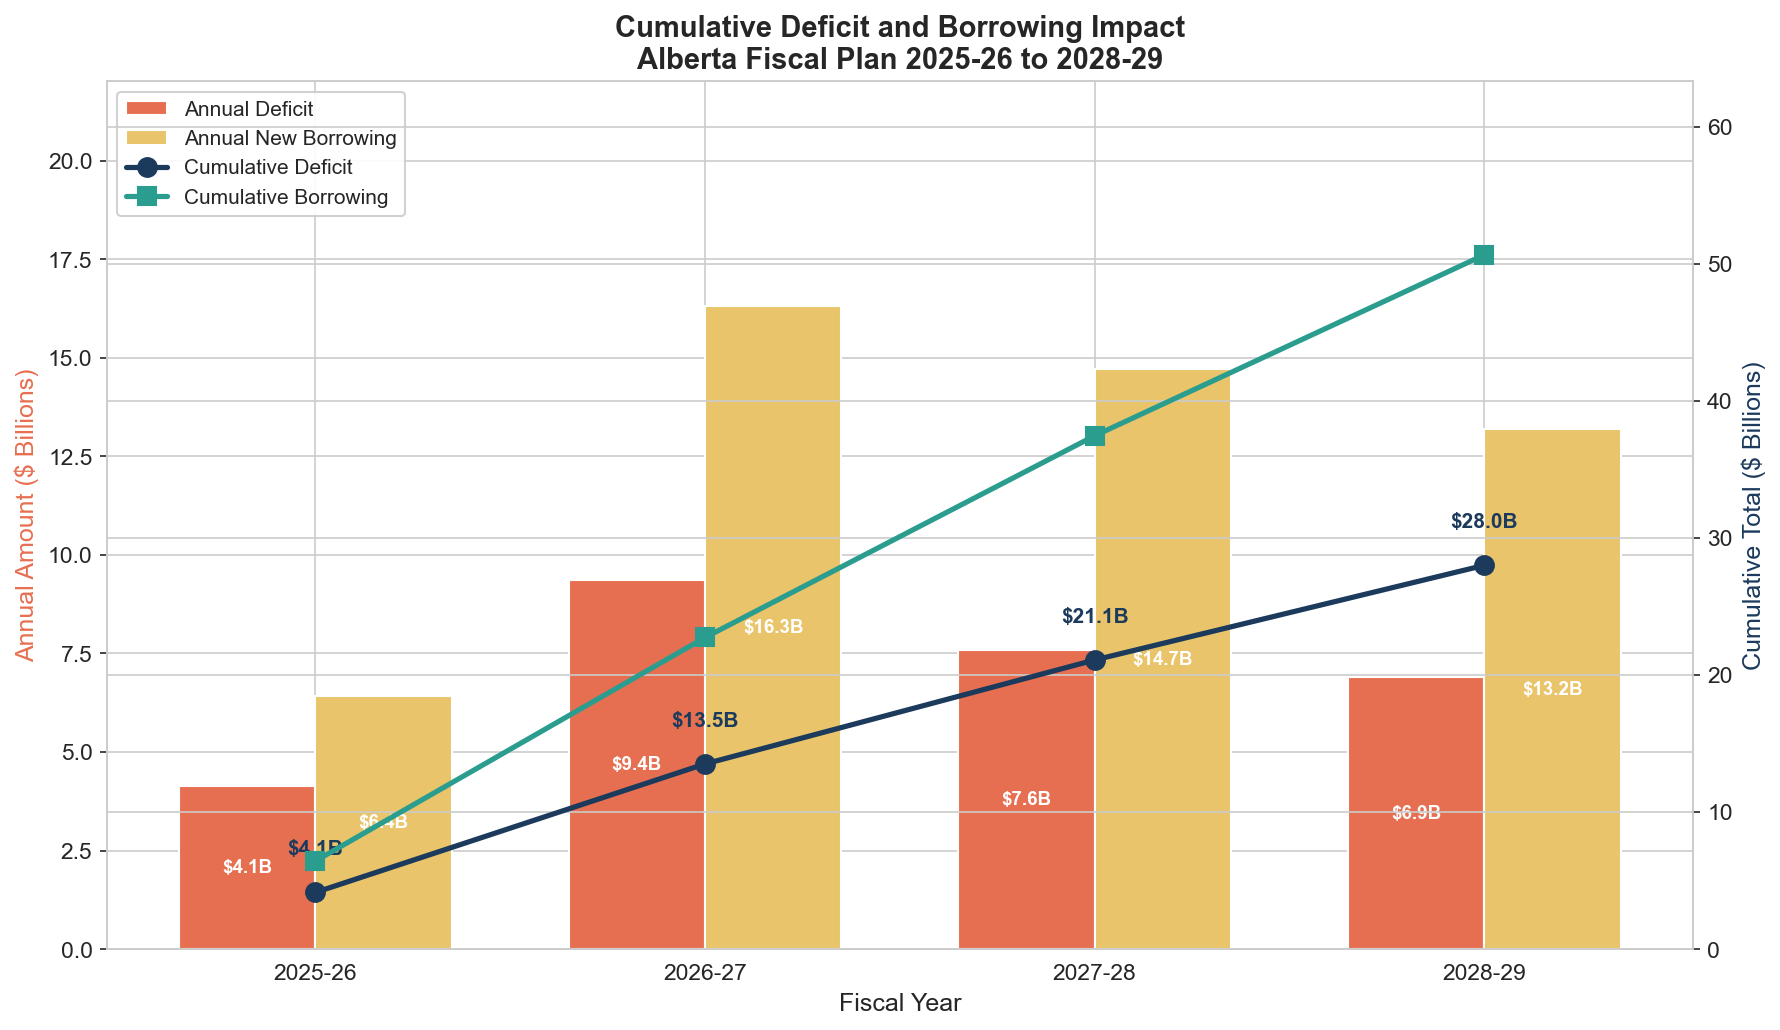

Total cumulative deficit 2025-26 to 2028-29: $28.0B
Total cumulative borrowing: $50.6B


In [2]:
# --- Cumulative Deficit Chart ---
years = ['2025-26', '2026-27', '2027-28', '2028-29']

# Annual deficits (negative = deficit) from fiscal summary
deficit_row = fiscal[fiscal['Item'] == 'Surplus / (deficit)'].iloc[0]
annual_deficits = [
    abs(deficit_row['2025-26 Forecast']),
    abs(deficit_row['2026-27 Estimate']),
    abs(deficit_row['2027-28 Target']),
    abs(deficit_row['2028-29 Target']),
]
cumulative = np.cumsum(annual_deficits)

# Annual borrowing
borrow_row = fiscal[fiscal['Item'] == 'Direct borrowing required'].iloc[0]
annual_borrowing = [
    borrow_row['2025-26 Forecast'],
    borrow_row['2026-27 Estimate'],
    borrow_row['2027-28 Target'],
    borrow_row['2028-29 Target'],
]
cumulative_borrowing = np.cumsum(annual_borrowing)

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(years))
width = 0.35

bars = ax.bar(x - width/2, [d / 1000 for d in annual_deficits], width,
              label='Annual Deficit', color=PALETTE['coral'], edgecolor='white', zorder=3)
bars2 = ax.bar(x + width/2, [b / 1000 for b in annual_borrowing], width,
               label='Annual New Borrowing', color=PALETTE['amber'], edgecolor='white', zorder=3)

ax2 = ax.twinx()
line1, = ax2.plot(x, [c / 1000 for c in cumulative], color=PALETTE['dark_blue'],
                  marker='o', linewidth=2.5, markersize=9, label='Cumulative Deficit', zorder=4)
line2, = ax2.plot(x, [c / 1000 for c in cumulative_borrowing], color=PALETTE['teal'],
                  marker='s', linewidth=2.5, markersize=9, label='Cumulative Borrowing', zorder=4)

# Annotate cumulative deficit values
for i, v in enumerate(cumulative):
    ax2.annotate(f'${v/1000:.1f}B', (x[i], v/1000), textcoords='offset points',
                 xytext=(0, 18), ha='center', fontweight='bold', fontsize=10, color=PALETTE['dark_blue'])

# Annotate bar values for annual deficits
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h / 2, f'${h:.1f}B',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Annotate bar values for annual borrowing
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h / 2, f'${h:.1f}B',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Annual Amount ($ Billions)', color=PALETTE['coral'])
ax2.set_ylabel('Cumulative Total ($ Billions)', color=PALETTE['dark_blue'])
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_title('Cumulative Deficit and Borrowing Impact\nAlberta Fiscal Plan 2025-26 to 2028-29')

# Combined legend
handles = list(bars.get_children()[:1]) + list(bars2.get_children()[:1]) + [line1, line2]
labels = ['Annual Deficit', 'Annual New Borrowing', 'Cumulative Deficit', 'Cumulative Borrowing']
ax.legend(handles, labels, loc='upper left', framealpha=0.9, fontsize=10)

ax.set_ylim(0, max(annual_borrowing)/1000 * 1.35)
ax2.set_ylim(0, max(cumulative_borrowing)/1000 * 1.25)

plt.tight_layout()
fig.savefig(OUT / 'cumulative_deficit.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Total cumulative deficit 2025-26 to 2028-29: ${cumulative[-1]/1000:.1f}B')
print(f'Total cumulative borrowing: ${cumulative_borrowing[-1]/1000:.1f}B')

## Health Spending Deep Dive

The three health-focused ministries (Hospital & Surgical, Primary & Preventative, Mental Health & Addiction) form the largest single spending block in the provincial budget. This chart tracks each over time and calculates their combined share of total program expense.

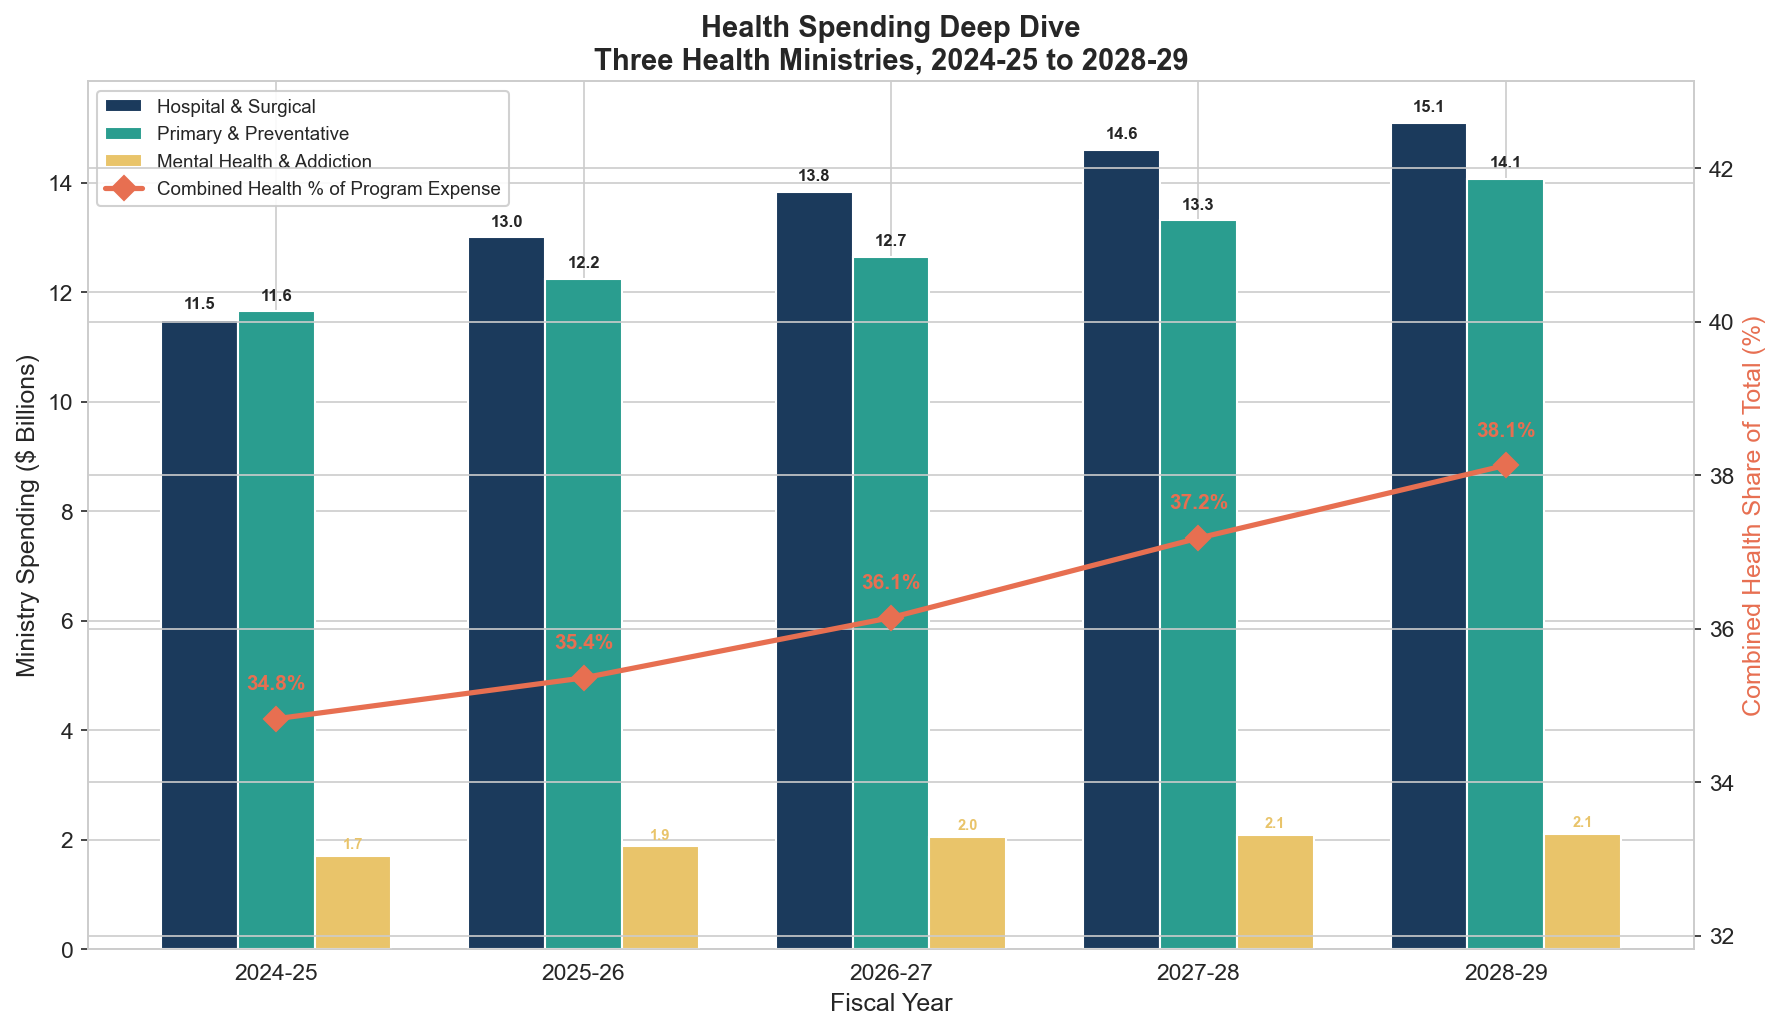

Combined health spending 2026-27: $28.5B
  = 36.1% of total program expense


In [3]:
# --- Health Spending Deep Dive ---
health_names = [
    'Hospital and Surgical Health Services',
    'Primary and Preventative Health Services',
    'Mental Health and Addiction',
]
year_cols = ['2024-25 Actual', '2025-26 Forecast', '2026-27 Estimate', '2027-28 Target', '2028-29 Target']
year_labels = ['2024-25', '2025-26', '2026-27', '2027-28', '2028-29']

health_df = ministry[ministry['Ministry'].isin(health_names)].copy()
health_df = health_df.set_index('Ministry')[year_cols]

total_row = ministry[ministry['Ministry'] == 'Total program expense'].iloc[0]
totals = [total_row[c] for c in year_cols]

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(year_labels))
width = 0.25

bar_colors = [PALETTE['dark_blue'], PALETTE['teal'], PALETTE['amber']]
short_labels = ['Hospital & Surgical', 'Primary & Preventative', 'Mental Health & Addiction']

for i, (name, short) in enumerate(zip(health_names, short_labels)):
    vals = [health_df.loc[name, c] / 1000 for c in year_cols]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=short,
                  color=bar_colors[i], edgecolor='white', zorder=3)
    for j, bar in enumerate(bars):
        h = bar.get_height()
        if h < 5:  # Mental Health bars are small (~1.7-2.1)
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.08,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold',
                    color=bar_colors[i])
        else:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                    f'{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Combined health % of total
combined = health_df.sum(axis=0)
pct_of_total = [(combined[c] / totals[j]) * 100 for j, c in enumerate(year_cols)]

ax2 = ax.twinx()
line, = ax2.plot(x, pct_of_total, color=PALETTE['coral'], marker='D', linewidth=2.5,
                 markersize=8, label='Combined Health % of Program Expense', zorder=4)
for i_pt, pct in enumerate(pct_of_total):
    ax2.annotate(f'{pct:.1f}%', (x[i_pt], pct), textcoords='offset points',
                 xytext=(0, 14), ha='center', fontweight='bold', fontsize=10, color=PALETTE['coral'])

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Ministry Spending ($ Billions)')
ax2.set_ylabel('Combined Health Share of Total (%)', color=PALETTE['coral'])
ax.set_xticks(x)
ax.set_xticklabels(year_labels)
ax.set_title('Health Spending Deep Dive\nThree Health Ministries, 2024-25 to 2028-29')

# Combined legend
handles_bars, labels_bars = ax.get_legend_handles_labels()
ax.legend(handles_bars + [line], labels_bars + ['Combined Health % of Program Expense'],
          loc='upper left', framealpha=0.9, fontsize=9)

ax2.set_ylim(min(pct_of_total) - 3, max(pct_of_total) + 5)

plt.tight_layout()
fig.savefig(OUT / 'health_spending_deep_dive.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Combined health spending 2026-27: ${combined["2026-27 Estimate"]/1000:.1f}B')
print(f'  = {pct_of_total[2]:.1f}% of total program expense')

## Per-Dollar Breakdown: Where Each Tax Dollar Goes

A citizen-friendly view of the 2026-27 budget: for every dollar of provincial revenue collected, how many cents flow to each major service area?

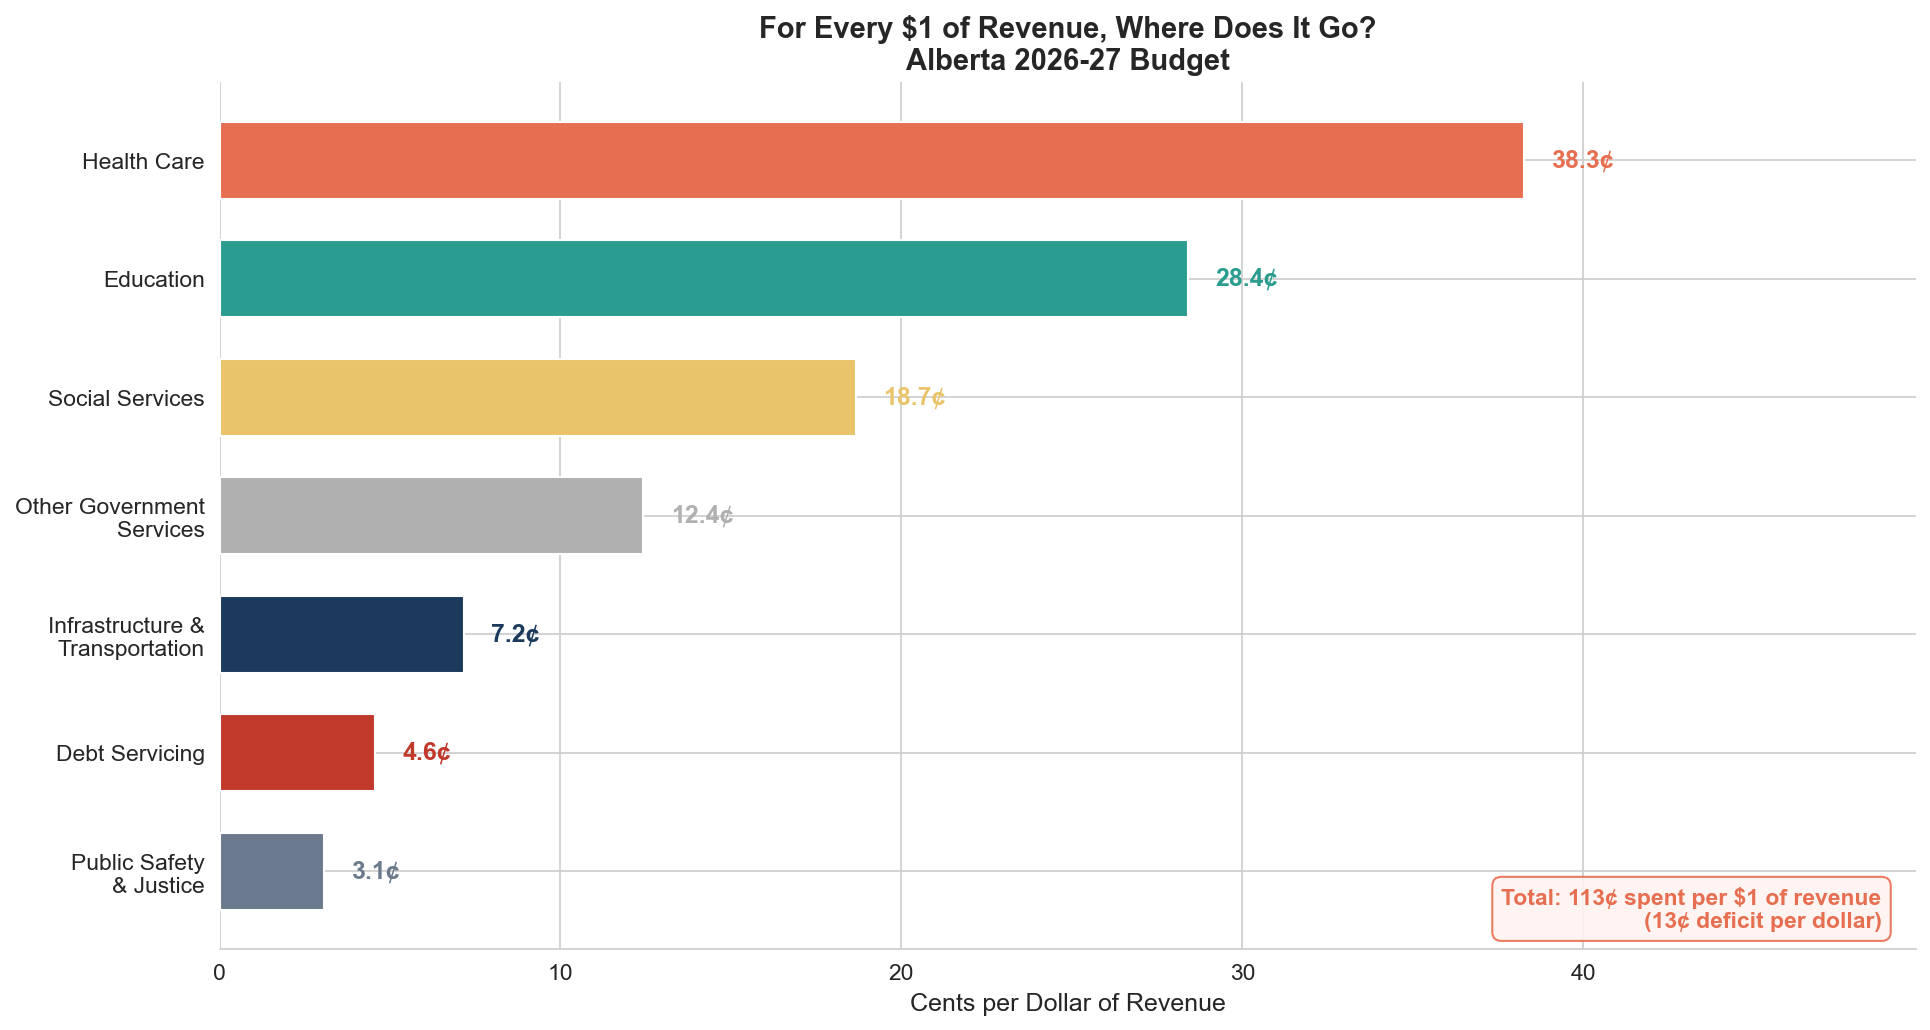

Total spending per $1 of revenue: 112.6 cents


In [4]:
# --- Per-Dollar Breakdown for 2026-27 ---
# Group ministries into citizen-friendly categories
categories = {
    'Health Care': ['Hospital and Surgical Health Services',
                    'Primary and Preventative Health Services',
                    'Mental Health and Addiction'],
    'Education': ['Education and Childcare', 'Advanced Education'],
    'Social Services': ['Assisted Living and Social Services', 'Children and Family Services'],
    'Infrastructure &\nTransportation': ['Infrastructure', 'Transportation and Economic Corridors',
                                          'Municipal Affairs'],
    'Public Safety\n& Justice': ['Public Safety and Emergency Services', 'Justice'],
}

col = '2026-27 Estimate'
total_revenue_2026 = 74550  # from fiscal summary

# Debt servicing
debt_serv_row_tp = fiscal[fiscal['Item'] == 'Taxpayer-supported debt servicing costs'].iloc[0]
debt_serv_row_ss = fiscal[fiscal['Item'] == 'Self-supported debt servicing costs'].iloc[0]
debt_servicing = debt_serv_row_tp[col] + debt_serv_row_ss[col]

cat_amounts = {}
for cat, ministries_list in categories.items():
    total = 0
    for m in ministries_list:
        row = ministry[ministry['Ministry'] == m]
        if len(row) > 0:
            total += row.iloc[0][col]
    cat_amounts[cat] = total

cat_amounts['Debt Servicing'] = debt_servicing

# "Other" = total expense - known categories - debt servicing
total_expense_2026 = 83922
known = sum(cat_amounts.values())
cat_amounts['Other Government\nServices'] = total_expense_2026 - known

# Convert to cents per dollar of revenue
cents = {k: (v / total_revenue_2026) * 100 for k, v in cat_amounts.items()}

# Sort by value descending
sorted_cats = sorted(cents.items(), key=lambda x: x[1], reverse=True)
labels_pd = [c[0] for c in sorted_cats]
values_pd = [c[1] for c in sorted_cats]

color_map = {
    'Health Care': PALETTE['coral'],
    'Education': PALETTE['teal'],
    'Social Services': PALETTE['amber'],
    'Infrastructure &\nTransportation': PALETTE['dark_blue'],
    'Public Safety\n& Justice': PALETTE['slate'],
    'Debt Servicing': '#C0392B',
    'Other Government\nServices': '#B0B0B0',
}
bar_colors_pd = [color_map.get(l, PALETTE['slate']) for l in labels_pd]

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(range(len(labels_pd)), values_pd, color=bar_colors_pd,
               edgecolor='white', height=0.65, zorder=3)

# Annotate each bar
for i, (bar, val) in enumerate(zip(bars, values_pd)):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}\u00a2', ha='left', va='center', fontweight='bold',
            fontsize=12, color=bar_colors_pd[i])

ax.set_yticks(range(len(labels_pd)))
ax.set_yticklabels(labels_pd, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Cents per Dollar of Revenue', fontsize=12)
ax.set_title('For Every $1 of Revenue, Where Does It Go?\nAlberta 2026-27 Budget', fontsize=14, fontweight='bold')

# Deficit callout
total_cents = sum(values_pd)
ax.text(0.98, 0.02, f'Total: {total_cents:.0f}\u00a2 spent per $1 of revenue\n'
        f'({total_cents - 100:.0f}\u00a2 deficit per dollar)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11, fontweight='bold', color=PALETTE['coral'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3F0', edgecolor=PALETTE['coral'], alpha=0.9))

ax.set_xlim(0, max(values_pd) * 1.30)
sns.despine(left=True)

plt.tight_layout()
fig.savefig(OUT / 'per_dollar_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Total spending per $1 of revenue: {total_cents:.1f} cents')

## Debt Servicing Cost Escalation

As deficits accumulate and borrowing rises, the cost of servicing Alberta's debt is projected to climb sharply. This chart tracks both absolute debt servicing costs and their share of total revenue, highlighting the point at which interest payments crowd out program spending.

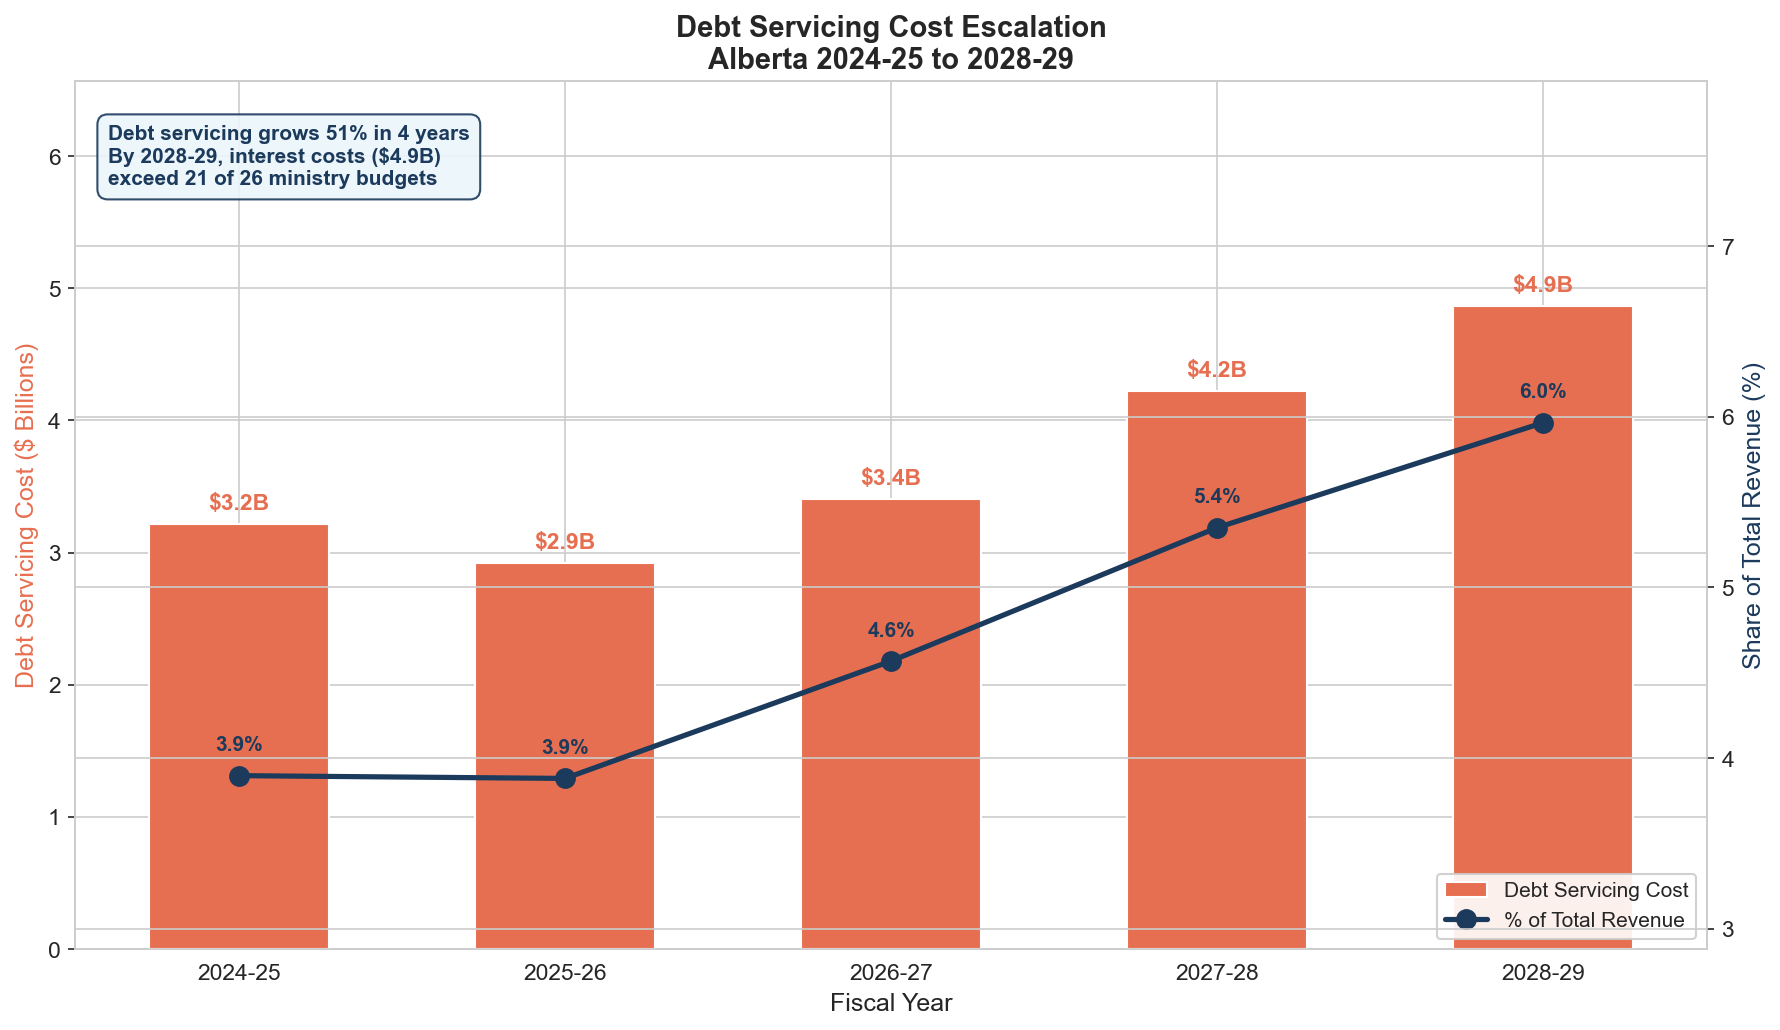

Debt servicing 2024-25: $3.2B -> 2028-29: $4.9B
Growth: 51%


In [5]:
# --- Debt Servicing Escalation ---
year_cols_full = ['2024-25 Actual', '2025-26 Forecast', '2026-27 Estimate', '2027-28 Target', '2028-29 Target']
year_labels_full = ['2024-25', '2025-26', '2026-27', '2027-28', '2028-29']

tp_row = fiscal[fiscal['Item'] == 'Taxpayer-supported debt servicing costs'].iloc[0]
ss_row = fiscal[fiscal['Item'] == 'Self-supported debt servicing costs'].iloc[0]

debt_serv_total = [tp_row[c] + ss_row[c] for c in year_cols_full]

# Revenue from fiscal summary
rev_row = fiscal[fiscal['Item'] == 'Total revenue'].iloc[0]
revenues = [rev_row[c] for c in year_cols_full]

pct_of_rev = [(ds / r) * 100 for ds, r in zip(debt_serv_total, revenues)]

# Find ministries smaller than debt servicing in 2028-29
debt_2028 = debt_serv_total[-1]
smaller_ministries = ministry[
    (ministry['2028-29 Target'] < debt_2028) &
    (ministry['Ministry'] != 'Total program expense')
]['Ministry'].tolist()

fig, ax = plt.subplots(figsize=(12, 7))

# Bars for absolute cost
bars = ax.bar(range(len(year_labels_full)), [d / 1000 for d in debt_serv_total],
              color=PALETTE['coral'], edgecolor='white', width=0.55, zorder=3, label='Debt Servicing Cost')

for bar, val in zip(bars, debt_serv_total):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'${val/1000:.1f}B', ha='center', va='bottom', fontweight='bold',
            fontsize=11, color=PALETTE['coral'])

# Line for % of revenue
ax2 = ax.twinx()
line, = ax2.plot(range(len(year_labels_full)), pct_of_rev, color=PALETTE['dark_blue'],
                 marker='o', linewidth=2.5, markersize=9, label='% of Total Revenue', zorder=4)
for i_pt, pct in enumerate(pct_of_rev):
    ax2.annotate(f'{pct:.1f}%', (i_pt, pct), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontweight='bold', fontsize=10, color=PALETTE['dark_blue'])

ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Debt Servicing Cost ($ Billions)', color=PALETTE['coral'])
ax2.set_ylabel('Share of Total Revenue (%)', color=PALETTE['dark_blue'])
ax.set_xticks(range(len(year_labels_full)))
ax.set_xticklabels(year_labels_full)
ax.set_title('Debt Servicing Cost Escalation\nAlberta 2024-25 to 2028-29')

# Annotation box
growth_pct = ((debt_serv_total[-1] - debt_serv_total[0]) / debt_serv_total[0]) * 100
ax.text(0.02, 0.95,
        f'Debt servicing grows {growth_pct:.0f}% in 4 years\n'
        f'By 2028-29, interest costs (${debt_2028/1000:.1f}B)\n'
        f'exceed {len(smaller_ministries)} of {len(ministry)-1} ministry budgets',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=10, fontweight='bold', color=PALETTE['dark_blue'],
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', edgecolor=PALETTE['dark_blue'], alpha=0.9))

# Combined legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc='lower right', framealpha=0.9, fontsize=10)

ax.set_ylim(0, max(debt_serv_total) / 1000 * 1.35)
ax2.set_ylim(min(pct_of_rev) - 1, max(pct_of_rev) + 2)

plt.tight_layout()
fig.savefig(OUT / 'debt_servicing_escalation.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Debt servicing 2024-25: ${debt_serv_total[0]/1000:.1f}B -> 2028-29: ${debt_serv_total[-1]/1000:.1f}B')
print(f'Growth: {growth_pct:.0f}%')

## Summary of Advanced Findings

Key insights synthesized from the cross-cutting analysis above, saved for the report writer.

In [6]:
# --- Save findings ---
findings = []

# Cumulative deficit
cum_def_total = sum(annual_deficits)
cum_borrow_total = sum(annual_borrowing)
findings.append('CUMULATIVE DEFICIT AND BORROWING')
findings.append(f'- Alberta will accumulate ${cum_def_total/1000:.1f}B in deficits from 2025-26 to 2028-29.')
findings.append(f'- Total new borrowing over the same period: ${cum_borrow_total/1000:.1f}B.')
findings.append(f'- Largest single-year deficit: ${max(annual_deficits)/1000:.1f}B in 2026-27.')
findings.append(f'- Borrowing far exceeds deficits because capital investment must also be financed.')
findings.append('')

# Health spending
health_2026 = combined['2026-27 Estimate']
health_2028 = combined['2028-29 Target']
findings.append('HEALTH SPENDING DEEP DIVE')
findings.append(f'- Combined health ministry spending in 2026-27: ${health_2026/1000:.1f}B ({pct_of_total[2]:.1f}% of program expense).')
findings.append(f'- By 2028-29, combined health reaches ${health_2028/1000:.1f}B ({pct_of_total[4]:.1f}% of program expense).')
findings.append(f'- Hospital & Surgical is the fastest-growing component, rising from $11.5B to $15.1B.')
findings.append(f'- Health spending alone accounts for more than a third of all program expense.')
findings.append('')

# Per-dollar breakdown
findings.append('PER-DOLLAR BREAKDOWN (2026-27)')
for lbl, val in sorted_cats:
    findings.append(f'- {lbl.replace(chr(10), " ")}: {val:.1f} cents per revenue dollar')
findings.append(f'- Total: {total_cents:.0f} cents spent per $1 of revenue (i.e. {total_cents-100:.0f}-cent deficit per dollar).')
findings.append('')

# Debt servicing
findings.append('DEBT SERVICING ESCALATION')
findings.append(f'- Debt servicing costs rise from ${debt_serv_total[0]/1000:.1f}B (2024-25) to ${debt_serv_total[-1]/1000:.1f}B (2028-29), a {growth_pct:.0f}% increase.')
findings.append(f'- As a share of revenue, debt servicing rises from {pct_of_rev[0]:.1f}% to {pct_of_rev[-1]:.1f}%.')
findings.append(f'- By 2028-29, debt servicing costs (${debt_2028/1000:.1f}B) exceed the individual budgets of {len(smaller_ministries)} of {len(ministry)-1} ministries.')
findings.append(f'- Total taxpayer-supported debt is projected to reach $137.5B by 2028-29, up from $85.2B in 2024-25.')

findings_text = '\n'.join(findings)

output_path = BASE / 'Revenue vs Expense Analysis' / 'advanced_findings.txt'
with open(output_path, 'w') as f:
    f.write(findings_text)

print('Advanced findings saved to:', output_path)
print()
print(findings_text)

Advanced findings saved to: C:\Users\Casper Ruta\Desktop\Kacper Ruta 2026\Alberta Budget Analysis\Revenue vs Expense Analysis\advanced_findings.txt

CUMULATIVE DEFICIT AND BORROWING
- Alberta will accumulate $28.0B in deficits from 2025-26 to 2028-29.
- Total new borrowing over the same period: $50.6B.
- Largest single-year deficit: $9.4B in 2026-27.
- Borrowing far exceeds deficits because capital investment must also be financed.

HEALTH SPENDING DEEP DIVE
- Combined health ministry spending in 2026-27: $28.5B (36.1% of program expense).
- By 2028-29, combined health reaches $31.3B (38.1% of program expense).
- Hospital & Surgical is the fastest-growing component, rising from $11.5B to $15.1B.
- Health spending alone accounts for more than a third of all program expense.

PER-DOLLAR BREAKDOWN (2026-27)
- Health Care: 38.3 cents per revenue dollar
- Education: 28.4 cents per revenue dollar
- Social Services: 18.7 cents per revenue dollar
- Other Government Services: 12.4 cents per rev